# Assigning Uncertainties

## Least-Squares Inversion of Gravity Anomaly Data with Depth Weighting

This tutorial (adapted from the original [SimPEG docs](https://docs.simpeg.xyz/v0.23.0/content/tutorials/03-gravity/plot_inv_1a_gravity_anomaly.html#sphx-glr-content-tutorials-03-gravity-plot-inv-1a-gravity-anomaly-py)) shows how to invert gravity anomaly data to recover a density-contrast model using a least-squares objective with depth weighting.  
  Here, we **vary the assigned data uncertainties** to see how they influence the data fit and the recovered model.

**We will:**
- Define the survey from `xyz`-formatted observations  
- Build a mesh from the survey geometry  
- Include surface topography and mark active cells  
- Set up the inverse problem (data misfit, regularization, optimization)  
- Add directives to control the solve  
- Compare recovered models and misfits under different **uncertainty** settings

<div style="text-align: center;">
  <img src="../images/simpeg/data_fit.png" alt="Data Fit" width="350"/>
</div>
<div style="height: 28px;"></div>

| Author                             | Contact                             |
| :---------------------------------- | :---------------------------------- |
| [Polyanna Rowe](https://github.com/polyye) | [polyannar@mirageoscience.com](mailto:polyannar@mirageoscience.com) |

## Import modules




In [1]:
import os
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import tarfile

from discretize import TensorMesh
from discretize.utils import active_from_xyz
from simpeg.utils import plot2Ddata, model_builder
from simpeg.potential_fields import gravity
from simpeg import (
    maps,
    data,
    data_misfit,
    inverse_problem,
    regularization,
    optimization,
    directives,
    inversion,
    utils,
)

# sphinx_gallery_thumbnail_number = 3

## Define File Names

File paths for assets we are loading. To set up the inversion, we require
topography and field observations. The true model defined on the whole mesh
is loaded to compare with the inversion result. These files are stored as a
tar-file on SimPEG's google cloud bucket:
"https://storage.googleapis.com/simpeg/doc-assets/gravity.tar.gz"




In [ ]:
# storage bucket the data is located
data_source = "https://storage.googleapis.com/simpeg/doc-assets/gravity.tar.gz"

# download the data
downloaded_data = utils.download(data_source, overwrite=True)

# unzip the tarfile
tar = tarfile.open(downloaded_data, "r")
tar.extractall()
tar.close()

# path to the directory containing our data
dir_path = downloaded_data.split(".")[0] + os.path.sep

# files to work with
topo_filename = dir_path + "gravity_topo.txt"
data_filename = dir_path + "gravity_data.obs"

   saved to: c:\Users\polyannar\OneDrive - Mira Geoscience Limited\Documents\Mira Geoscience\Projects\5415 - Deloitte Brazil Inversion and AEM training\simpeg-drivers-develop\docs\tutorials\SimPEG_tutorials_python_code\gravity.tar.gz
Download completed!


## Load Data and Plot

Here we load and plot synthetic gravity anomaly data. Topography is generally
defined as an (N, 3) array. Gravity data is generally defined with 4 columns:
x, y, z and data.




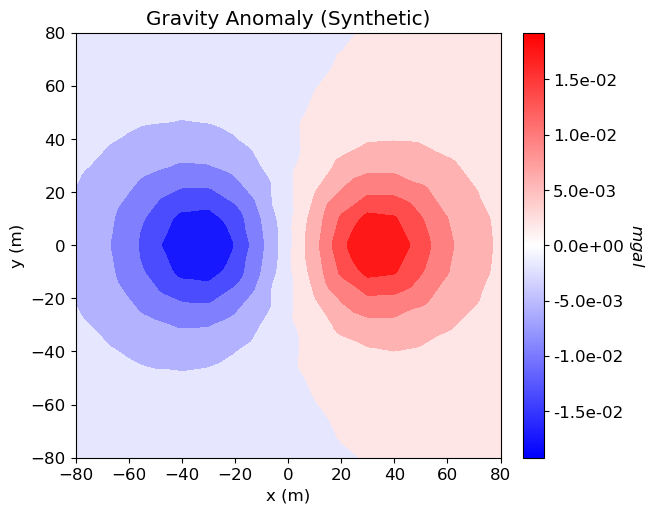

In [3]:
# Load topography
xyz_topo = np.loadtxt(str(topo_filename))

# Load field data
dobs = np.loadtxt(str(data_filename))

# Define receiver locations and observed data
receiver_locations = dobs[:, 0:3]
dobs = dobs[:, -1]

# Plot
mpl.rcParams.update({"font.size": 12})
fig = plt.figure(figsize=(7, 5))

ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.85])
plot2Ddata(receiver_locations, 
           dobs * -1, # SimPEG uses right handed coordinate where Z is positive upward
           ax=ax1, contourOpts={"cmap": "bwr"})
ax1.set_title("Gravity Anomaly (Synthetic)")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")

ax2 = fig.add_axes([0.8, 0.1, 0.03, 0.85])
norm = mpl.colors.Normalize(vmin=-np.max(np.abs(dobs)), vmax=np.max(np.abs(dobs)))
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.bwr, format="%.1e"
)
cbar.set_label("$mgal$", rotation=270, labelpad=15, size=12)

plt.show()

## Adding Noise to the Observations

We add synthetic noise to the gravity anomaly data to mimic real acquisition conditions and test how inversions respond to **different noise levels**.

**How we add noise:** draw Gaussian noise $n \sim \mathcal{N}(0,\sigma)$ and set $ d_{\text{noisy}} = d_{\text{clean}} + n $.
- **Choosing $\sigma$ for the inversion:**
  - **Uniform (global) uncertainty:** Here we are using $ \sigma = \alpha \,\max|d_{\text{noisy}}| $ (for instance, $\alpha = 0.05$, i.e. five percent of the maximum amplitude).
- **Uncertainties in SimPEG:** pass the same $\sigma$ (or vector $\{\sigma_i\}$) to `standard_deviation` in `SimPEG.Data`.  
  If the noise model matches reality, the normalized misfit should trend toward $\chi^2/N \approx 1$.
- **Reproducibility:** set a fixed random seed before generating noise.

By changing $\alpha$, you can quickly assess how data fit, model roughness, and convergence change under different noise assumptions.


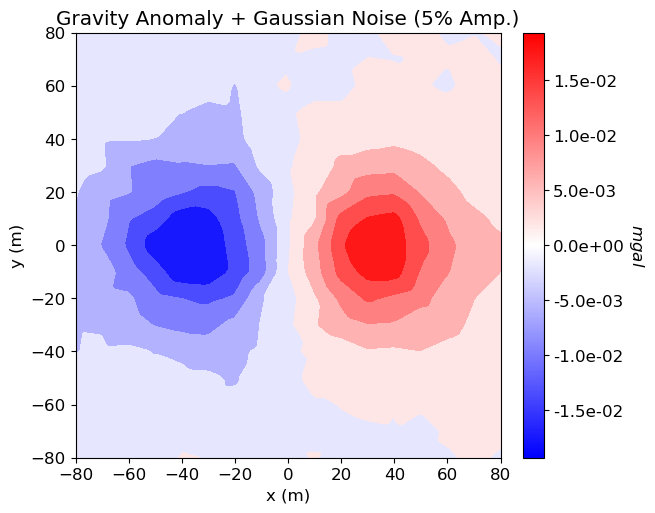

In [5]:
# Keep a clean copy
dobs_clean = dobs.astype(float).copy()

# ---- Choose a noise level & add noise ----
rng = np.random.default_rng(42)       # (seed=42) reproducible noise
noise_frac = 0.05                     # We are adding this amount of noise: 5% of the max amplitude
sigma = noise_frac * np.nanmax(np.abs(dobs_clean))  # standard deviation of noise

noise = rng.normal(loc=0.0, scale=sigma, size=dobs_clean.shape)
dobs = dobs_clean + noise             # noisy observations

# Plot
mpl.rcParams.update({"font.size": 12})
fig = plt.figure(figsize=(7, 5))

ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.85])
plot2Ddata(receiver_locations, 
           dobs * -1, # SimPEG uses right handed coordinate where Z is positive upward
           ax=ax1, contourOpts={"cmap": "bwr"})
ax1.set_title("Gravity Anomaly + Gaussian Noise (5% Amp.)")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")

ax2 = fig.add_axes([0.8, 0.1, 0.03, 0.85])
norm = mpl.colors.Normalize(vmin=-np.max(np.abs(dobs)), vmax=np.max(np.abs(dobs)))
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.bwr, format="%.1e"
)
cbar.set_label("$mgal$", rotation=270, labelpad=15, size=12)

plt.show()

## Assign Uncertainties

Inversion with SimPEG requires that we define the standard deviation of our data. This represents our estimate of the noise in our data. For a gravity inversion, a constant floor value is generally applied to all data.

### **First pass** (when assigned uncertainties are too high):

Set the same floor for all data,
$
\sigma \;=\; 0.12 \,\max\!\big|d_{\text{obs}}\big|
$
i.e., **12% of the maximum absolute observed anomaly**. This is intentionally conservative (above the injected noise). We will see what happens to the inversion and recovered model under these conditions.

> 💡 **Note:**
> - You can pass a **scalar** (uniform $\sigma$) or a **vector** (per-datum $\sigma_i$) to `standard_deviation` in `SimPEG.Data`.
> - Alternative option: per-datum **relative + floor**, i.e., $\sigma_i = r\,|d_i| + f$.  




In [5]:
maximum_anomaly = np.max(np.abs(dobs))

# Assigning uncertainties that are too high
uncertainties = 0.12 * maximum_anomaly * np.ones(np.shape(dobs)) # 12% of the max anomaly

## Defining the Survey

Here, we define the survey that will be used for this tutorial. Gravity
surveys are simple to create. The user only needs an (N, 3) array to define
the xyz locations of the observation locations. From this, the user can
define the receivers and the source field.




In [8]:
# Define the receivers. The data consists of vertical gravity anomaly measurements.
# The set of receivers must be defined as a list.
receiver_list = gravity.receivers.Point(receiver_locations, components="gz")

receiver_list = [receiver_list]

# Define the source field
source_field = gravity.sources.SourceField(receiver_list=receiver_list)

# Define the survey
survey = gravity.survey.Survey(source_field)

## Defining the Data

Here is where we define the data that is inverted. The data is defined by
the survey, the observation values and the standard deviation.




In [9]:
data_object = data.Data(survey, dobs=dobs, standard_deviation=uncertainties)

## Defining a Tensor Mesh

Here, we create the tensor mesh that will be used to invert gravity anomaly
data. If desired, we could define an OcTree mesh.




In [10]:
dh = 5.0
hx = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)]
hy = [(dh, 5, -1.3), (dh, 40), (dh, 5, 1.3)]
hz = [(dh, 5, -1.3), (dh, 15)]
mesh = TensorMesh([hx, hy, hz], "CCN")

## Starting/Reference Model and Mapping on Tensor Mesh

Here, we create starting and/or reference models for the inversion as
well as the mapping from the model space to the active cells. Starting and
reference models can be a constant background value or contain a-priori
structures.




In [11]:
# Find the indices of the active cells in forward model (ones below surface)
ind_active = active_from_xyz(mesh, xyz_topo)

# Define mapping from model to active cells
nC = int(ind_active.sum())
model_map = maps.IdentityMap(nP=nC)  # model consists of a value for each active cell

# Define and plot starting model (density contrast of 0 g/cc)
starting_model = np.zeros(nC)

## Define the Physics

Here, we define the physics of the gravity problem by using the simulation
class.




In [12]:
simulation = gravity.simulation.Simulation3DIntegral(
    survey=survey,
    mesh=mesh,
    rhoMap=model_map,
    active_cells=ind_active,
)

## Define the Inverse Problem

The inverse problem is defined by 3 things:

1) ***Data Misfit:*** a measure of how well our recovered model explains the field data
2) ***Regularization:*** constraints placed on the recovered model and a priori information
3) ***Optimization:*** the numerical approach used to solve the inverse problem




In [13]:
# Define the data misfit. Here the data misfit is the L2 norm of the weighted
# residual between the observed data and the data predicted for a given model.
# Within the data misfit, the residual between predicted and observed data are
# normalized by the data's standard deviation.
dmis = data_misfit.L2DataMisfit(data=data_object, simulation=simulation)

# Define the regularization (model objective function).
reg = regularization.WeightedLeastSquares(
    mesh, active_cells=ind_active, mapping=model_map
)

# Add depth weighting to the regularization
depth_weights = utils.depth_weighting(
    mesh, receiver_locations, active_cells=ind_active, exponent=2
)
reg.set_weights(depth_weights=depth_weights)

# Define how the optimization problem is solved. Here we will use a projected
# Gauss-Newton approach that employs the conjugate gradient solver.
opt = optimization.ProjectedGNCG(
    maxIter=40, lower=-1.0, upper=1.0, maxIterLS=20, maxIterCG=10, tolCG=1e-3
)

# Here we define the inverse problem that is to be solved
inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt)

## Define Inversion Directives

Here we define any directiveas that are carried out during the inversion. This
includes the cooling schedule for the trade-off parameter (beta), stopping
criteria for the inversion and saving inversion results at each iteration.




In [14]:
# Defining a starting value for the trade-off parameter (beta) between the data
# misfit and the regularization.
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=20)

# Defining the fractional decrease in beta and the number of Gauss-Newton solves
# for each beta value.
beta_schedule = directives.BetaSchedule(coolingFactor=2, coolingRate=1)

# Options for outputting recovered models and predicted data for each beta.
save_iteration = directives.SaveOutputEveryIteration(save_txt=False)

# Updating the preconditionner if it is model dependent.
update_jacobi = directives.UpdatePreconditioner()

# Setting a stopping criteria for the inversion.
target_misfit = directives.TargetMisfit(chifact=1)

# Add sensitivity weights
sensitivity_weights = directives.UpdateSensitivityWeights(every_iteration=False)

# The directives are defined as a list.
directives_list = [
    sensitivity_weights,
    starting_beta,
    beta_schedule,
    save_iteration,
    update_jacobi,
    target_misfit,
]

## Running the Inversion

To define the inversion object, we need to define the inversion problem and
the set of directives. We can then run the inversion.




In [15]:
# Here we combine the inverse problem and the set of directives
inv = inversion.BaseInversion(inv_prob, directives_list)

# Run inversion
recovered_model = inv.run(starting_model)


Running inversion with SimPEG v0.23.0.1.post2.dev38+mira.ga1cf0ec4a
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.
simpeg.InvProblem will set Regularization.reference_model to m0.

                    simpeg.InvProblem is setting bfgsH0 to the inverse of the eval2Deriv.
                    ***Done using the default solver Pardiso and no solver_opts.***
                    
model has any nan: 0
=============================== Projected GNCG ===============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
x0 has any nan: 0
   0  

## Recreate True Model

This is our true model, i.e., the original synthetic model the recovers the gravity anomaly prior to noise addition:




In [16]:
# Define density contrast values for each unit in g/cc
background_density = 0.0
block_density = -0.2
sphere_density = 0.2

# Define model. Models in SimPEG are vector arrays.
true_model = background_density * np.ones(nC)

# You could find the indicies of specific cells within the model and change their
# value to add structures.
ind_block = (
    (mesh.gridCC[ind_active, 0] > -50.0)
    & (mesh.gridCC[ind_active, 0] < -20.0)
    & (mesh.gridCC[ind_active, 1] > -15.0)
    & (mesh.gridCC[ind_active, 1] < 15.0)
    & (mesh.gridCC[ind_active, 2] > -50.0)
    & (mesh.gridCC[ind_active, 2] < -30.0)
)
true_model[ind_block] = block_density

# You can also use SimPEG utilities to add structures to the model more concisely
ind_sphere = model_builder.get_indices_sphere(
    np.r_[35.0, 0.0, -40.0], 15.0, mesh.gridCC
)
ind_sphere = ind_sphere[ind_active]
true_model[ind_sphere] = sphere_density

## Plotting True Model and Recovered Model for the **First Pass**

i.e. the model recovered from an inversion considering assigned uncertainties of 12% of the maximum absolute observed anomaly.

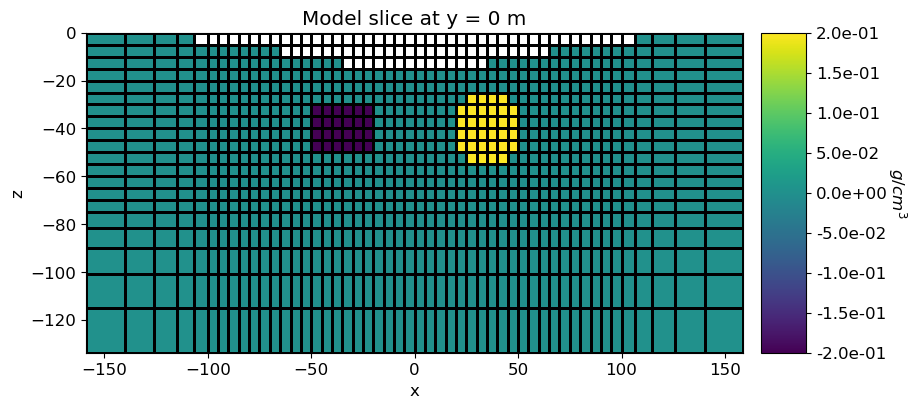

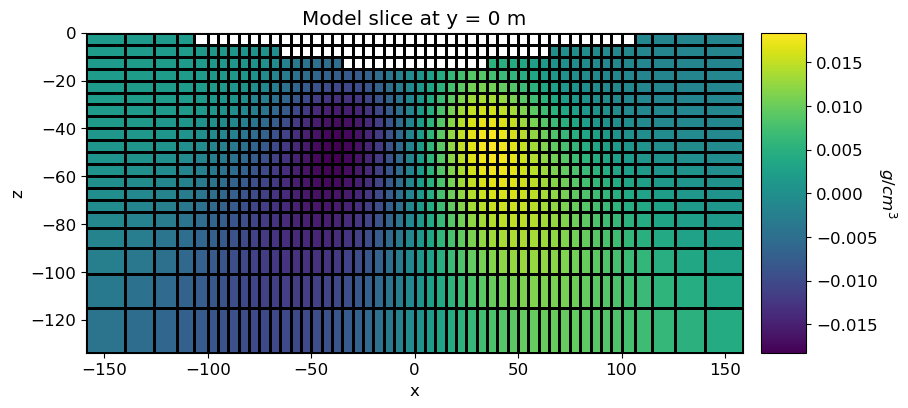

In [17]:
# Plot True Model
fig = plt.figure(figsize=(9, 4))
plotting_map = maps.InjectActiveCells(mesh, ind_active, np.nan)

ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])
mesh.plot_slice(
    plotting_map * true_model,
    normal="Y",
    ax=ax1,
    ind=int(mesh.shape_cells[1] / 2),
    grid=True,
    clim=(np.min(true_model), np.max(true_model)),
    pcolor_opts={"cmap": "viridis"},
)
ax1.set_title("Model slice at y = 0 m")


ax2 = fig.add_axes([0.85, 0.1, 0.05, 0.8])
norm = mpl.colors.Normalize(vmin=np.min(true_model), vmax=np.max(true_model))
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.viridis, format="%.1e"
)
cbar.set_label("$g/cm^3$", rotation=270, labelpad=15, size=12)

plt.show()

# Plot Recovered Model
fig = plt.figure(figsize=(9, 4))
plotting_map = maps.InjectActiveCells(mesh, ind_active, np.nan)

ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])
mesh.plot_slice(
    plotting_map * recovered_model,
    normal="Y",
    ax=ax1,
    ind=int(mesh.shape_cells[1] / 2),
    grid=True,
    clim=(np.min(recovered_model), np.max(recovered_model)),
    pcolor_opts={"cmap": "viridis"},
)
ax1.set_title("Model slice at y = 0 m")

ax2 = fig.add_axes([0.85, 0.1, 0.05, 0.8])
norm = mpl.colors.Normalize(vmin=np.min(recovered_model), vmax=np.max(recovered_model))
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.viridis
)
cbar.set_label("$g/cm^3$", rotation=270, labelpad=15, size=12)

plt.show()

## Plotting Predicted Data and Normalized Misfit for the **First Pass**

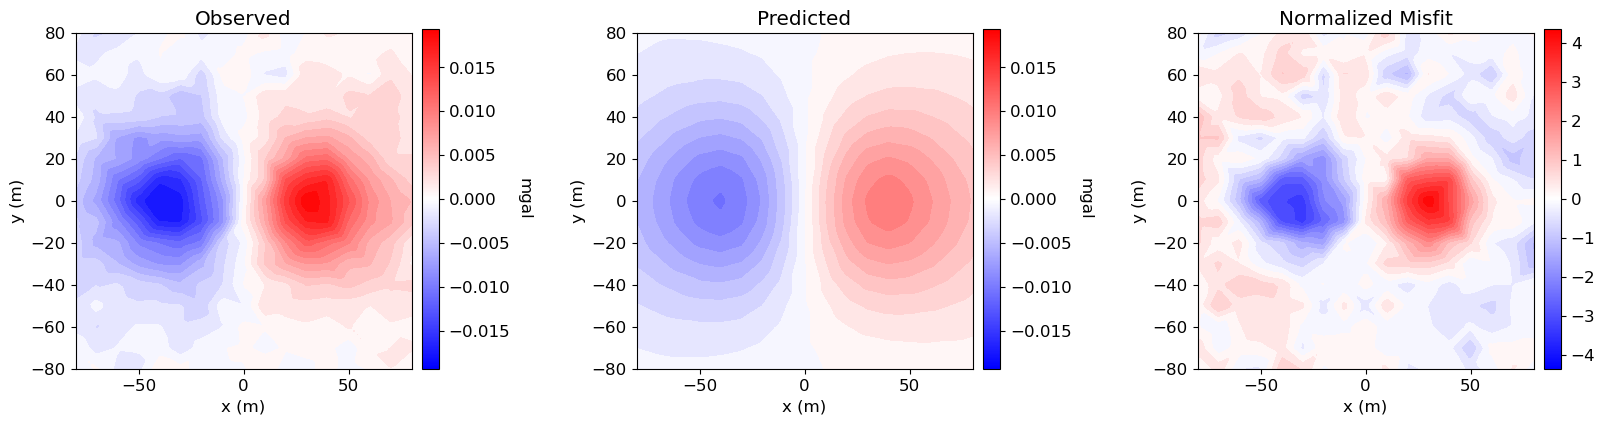

In [18]:
# Predicted data with final recovered model
# SimPEG uses right handed coordinate where Z is positive upward.
# This causes gravity signals look "inconsistent" with density values in visualization. Therefore we multiply by -1.
dpred_zconv = np.asarray(inv_prob.dpred[0].ravel())* -1
dobs_zconv = np.asarray(dobs.ravel())* -1

# Observed data | Predicted data | Normalized data misfit
data_array = np.c_[dobs_zconv, dpred_zconv, (dobs_zconv - dpred_zconv) / uncertainties]

fig = plt.figure(figsize=(17, 4))
plot_title = ["Observed", "Predicted", "Normalized Misfit"]
plot_units = ["mgal", "mgal", ""]

ax1 = 3 * [None]
ax2 = 3 * [None]
norm = 3 * [None]
cbar = 3 * [None]
cplot = 3 * [None]
v_lim = [np.max(np.abs(dobs)), np.max(np.abs(dobs)), np.max(np.abs(data_array[:, 2]))]

for ii in range(0, 3):
    ax1[ii] = fig.add_axes([0.33 * ii + 0.03, 0.11, 0.23, 0.84])
    cplot[ii] = plot2Ddata(
        receiver_list[0].locations,
        data_array[:, ii],
        ax=ax1[ii],
        ncontour=30,
        clim=(-v_lim[ii], v_lim[ii]),
        contourOpts={"cmap": "bwr"},
    )
    ax1[ii].set_title(plot_title[ii])
    ax1[ii].set_xlabel("x (m)")
    ax1[ii].set_ylabel("y (m)")

    ax2[ii] = fig.add_axes([0.33 * ii + 0.25, 0.11, 0.01, 0.85])
    norm[ii] = mpl.colors.Normalize(vmin=-v_lim[ii], vmax=v_lim[ii])
    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="vertical", cmap=mpl.cm.bwr
    )
    cbar[ii].set_label(plot_units[ii], rotation=270, labelpad=15, size=12)

plt.show()

## Plot Profile of Predicted Data and Normalized Misfit for the **First Pass**

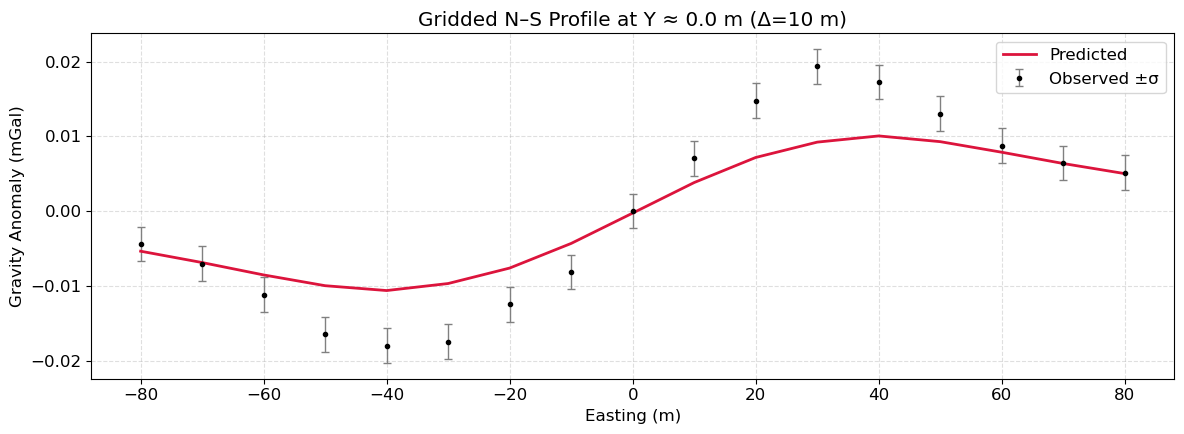

In [19]:
# --- Grid data, then extract a Y=0 profile for observed & predicted (with ±uncertainty) ---

from scipy.interpolate import griddata

# Inputs
xy = receiver_list[0].locations[:, :2]                  # (Easting, Northing)
dobs_zconv = dobs.ravel() * -1
dpred_zconv = np.asarray(inv_prob.dpred[0]).ravel() * -1
unc  = uncertainties.ravel()

# Regular grid
grid_res = 10.0                                         # meters
xi = np.arange(xy[:,0].min(), xy[:,0].max()+grid_res, grid_res)
yi = np.arange(xy[:,1].min(), xy[:,1].max()+grid_res, grid_res)
GX, GY = np.meshgrid(xi, yi)

def grid_with_fill(xy, v):
    g = griddata(xy, v, (GX, GY), method="linear")
    g_nn = griddata(xy, v, (GX, GY), method="nearest")
    return np.where(np.isnan(g), g_nn, g)

obs_g = grid_with_fill(xy, dobs_zconv)
pre_g = grid_with_fill(xy, dpred_zconv)
err_g = grid_with_fill(xy, unc)

# Extract profile at Y ≈ 0 (closest grid row)
y_target = 0.0
iy = np.argmin(np.abs(yi - y_target))
y_val = yi[iy]

x_prof  = xi
obs_prof = obs_g[iy, :]
pre_prof = pre_g[iy, :]
err_prof = err_g[iy, :]

# Mask any remaining NaNs (edges)
m = ~np.isnan(obs_prof) & ~np.isnan(pre_prof) & ~np.isnan(err_prof)
x_prof, obs_prof, pre_prof, err_prof = x_prof[m], obs_prof[m], pre_prof[m], err_prof[m]

# Plot
plt.figure(figsize=(12, 4.5))
plt.errorbar(x_prof, obs_prof, yerr=err_prof, fmt='o', ms=3, color='k',
             ecolor='0.5', elinewidth=1, capsize=3, label='Observed ±σ')
plt.plot(x_prof, pre_prof, '-', lw=2, color='crimson', label='Predicted')
plt.xlabel("Easting (m)")
plt.ylabel("Gravity Anomaly (mGal)")
plt.title(f"Gridded N–S Profile at Y ≈ {y_val:.1f} m (Δ={grid_res:.0f} m)")
plt.grid(True, ls='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


### Result: Noise Floor Set Too High

- **Objective function:**  
  $
  \phi(m) \;=\; \underbrace{\|\,W_d\,(d_\text{obs}-d_\text{pred}(m))\|_2^2}_{\phi_d \text{ (data misfit)}} \;+\; \beta\,\underbrace{\phi_m(m)}_{\text{regularization}}
  $  
    
- **Data weighting:** $W_d = \mathrm{diag}(1/\sigma_i)$, where $\sigma_i$ is the **standard deviation (uncertainty)** you assign to each datum.


If you pick a **noise floor** that’s **too large** (e.g., 12% when the true/injected noise is ~5%):

1. **Data are down-weighted.**  
   Larger $\sigma_i \Rightarrow$ smaller weights $1/\sigma_i$. The data-misfit $\phi_d$ counts less in $\phi(m)$, so the solver can “afford” to ignore some mismatch.

2. **Regularization takes over.**  
   Because $\phi_d$ stays small, the optimizer mostly minimizes $\phi_m$ (the smoothness term). The result is an **over-smoothed, low-contrast** model with blurred edges.

3. **Underfitting shows up.**  
   Residuals $(d_\text{obs}-d_\text{pred})$ display **structured** (geology-like) patterns instead of random noise. That means real signal was **not** explained by the model.

4. **Beta schedule can mislead.**  
   With large uncertainties, the target misfit $\phi_d \approx N$ is reached **too easily**. The inversion may stop early even though the physics isn’t well fit.


---

## Changing the uncertainty and rerunning inversion

### **Second pass** (when assigned uncertainties are too low):

Now we assign an uncertainty floor of **1%** of the maximum absolute observed anomaly.


In [20]:
# Reassigning uncertainties
uncertainties = 0.01 * maximum_anomaly * np.ones(np.shape(dobs)) # 1% of the max anomaly

# Reassign data object
data_object = data.Data(survey, dobs=dobs, standard_deviation=uncertainties)

# Data misfit term
dmis = data_misfit.L2DataMisfit(data=data_object, simulation=simulation)

# Inverse problem
inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt)

# Here we combine the inverse problem and the set of directives
inv = inversion.BaseInversion(inv_prob, directives_list)

# Re-run inversion
recovered_model_2 = inv.run(starting_model)

c:\Users\polyannar\.conda\envs\simpeg_drivers\lib\site-packages\simpeg\directives\directives.py:350: UserWarning: InversionDirective UpdateSensitivityWeights has switched to a new inversion.
  d.inversion = i
c:\Users\polyannar\.conda\envs\simpeg_drivers\lib\site-packages\simpeg\directives\directives.py:350: UserWarning: InversionDirective BetaEstimate_ByEig has switched to a new inversion.
  d.inversion = i
c:\Users\polyannar\.conda\envs\simpeg_drivers\lib\site-packages\simpeg\directives\directives.py:350: UserWarning: InversionDirective BetaSchedule has switched to a new inversion.
  d.inversion = i
c:\Users\polyannar\.conda\envs\simpeg_drivers\lib\site-packages\simpeg\directives\directives.py:350: UserWarning: InversionDirective SaveOutputEveryIteration has switched to a new inversion.
  d.inversion = i
c:\Users\polyannar\.conda\envs\simpeg_drivers\lib\site-packages\simpeg\directives\directives.py:350: UserWarning: InversionDirective UpdatePreconditioner has switched to a new invers

The callback on the ProjectedGNCG Optimization was replaced.

Running inversion with SimPEG v0.23.0.1.post2.dev38+mira.ga1cf0ec4a

                    simpeg.InvProblem is setting bfgsH0 to the inverse of the eval2Deriv.
                    ***Done using the default solver Pardiso and no solver_opts.***
                    
model has any nan: 0
=============================== Projected GNCG ===============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
x0 has any nan: 0
   0  8.08e+02  2.72e+05  0.00e+00  2.72e+05    2.19e+02      0   Skip BFGS  
   1  4.04e+02  4.79e+03  5.49e+00  7.00e+03    2.17e+02      0   Skip BFGS  
   2  2.02e+02  3.12e+03  7.16e+00  4.57e+03    2.15e+02      0   Skip BFGS  
   3  1.01e+02  2.29e+03  9.37e+00  3.24e+03    2.15e+02      0   Skip BFGS  
   4  5.05e+01  1.88e+03  1.14e+01  2.45e+03    2.15e+02      0              
   5  2.53

## Plotting True Model and Recovered Model for the **Second Pass**

i.e. the model recovered from an inversion considering assigned uncertainties of 1% of the maximum absolute observed anomaly.

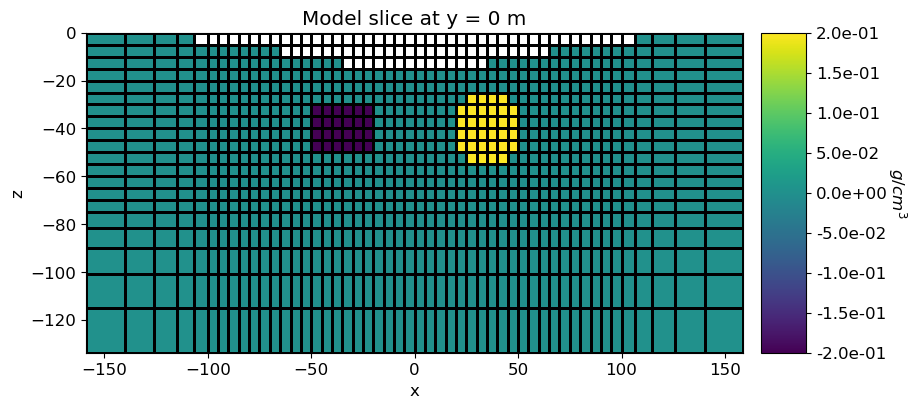

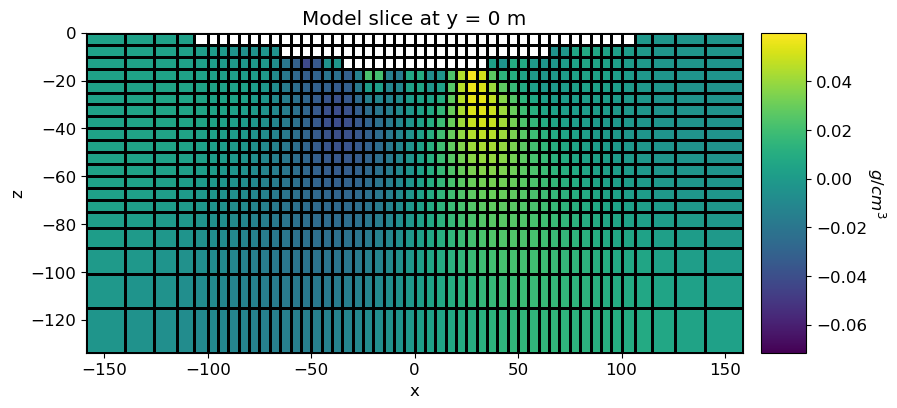

In [21]:
# Plot True Model
fig = plt.figure(figsize=(9, 4))
plotting_map = maps.InjectActiveCells(mesh, ind_active, np.nan)

ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])
mesh.plot_slice(
    plotting_map * true_model,
    normal="Y",
    ax=ax1,
    ind=int(mesh.shape_cells[1] / 2),
    grid=True,
    clim=(np.min(true_model), np.max(true_model)),
    pcolor_opts={"cmap": "viridis"},
)
ax1.set_title("Model slice at y = 0 m")


ax2 = fig.add_axes([0.85, 0.1, 0.05, 0.8])
norm = mpl.colors.Normalize(vmin=np.min(true_model), vmax=np.max(true_model))
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.viridis, format="%.1e"
)
cbar.set_label("$g/cm^3$", rotation=270, labelpad=15, size=12)

plt.show()

# Plot Recovered Model
fig = plt.figure(figsize=(9, 4))
plotting_map = maps.InjectActiveCells(mesh, ind_active, np.nan)

ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])
mesh.plot_slice(
    plotting_map * recovered_model_2,
    normal="Y",
    ax=ax1,
    ind=int(mesh.shape_cells[1] / 2),
    grid=True,
    clim=(np.min(recovered_model_2), np.max(recovered_model_2)),
    pcolor_opts={"cmap": "viridis"},
)
ax1.set_title("Model slice at y = 0 m")

ax2 = fig.add_axes([0.85, 0.1, 0.05, 0.8])
norm = mpl.colors.Normalize(vmin=np.min(recovered_model_2), vmax=np.max(recovered_model_2))
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.viridis
)
cbar.set_label("$g/cm^3$", rotation=270, labelpad=15, size=12)

plt.show()

## Plotting Predicted Data and Normalized Misfit for the **Second Pass**

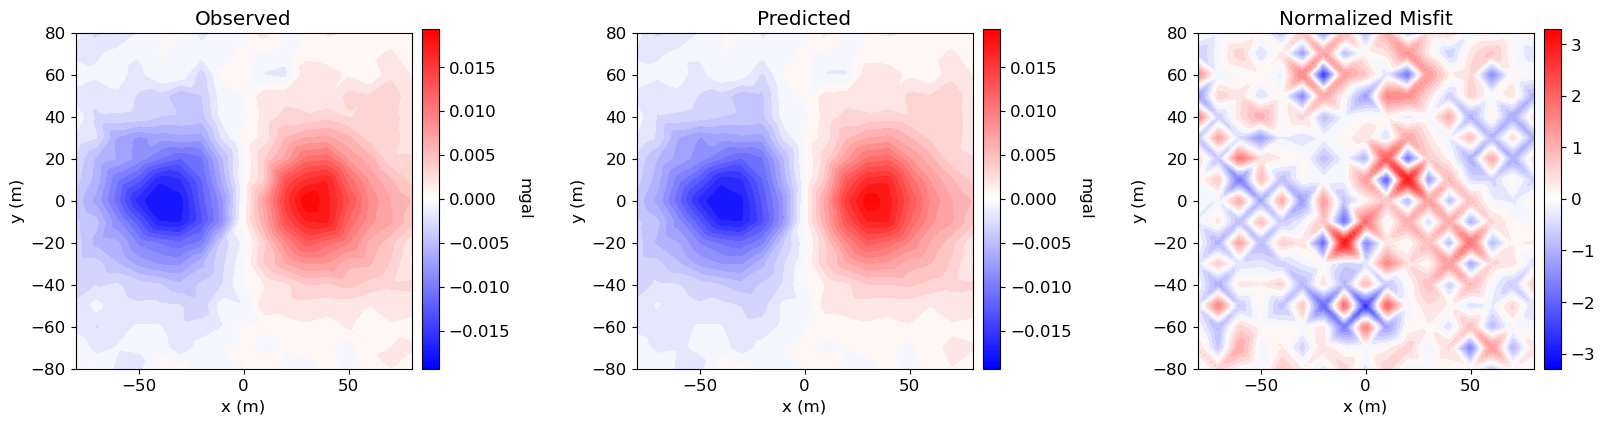

In [22]:
# Predicted data with final recovered model
# SimPEG uses right handed coordinate where Z is positive upward.
# This causes gravity signals look "inconsistent" with density values in visualization. Therefore we multiply by -1.
dpred_zconv = np.asarray(inv_prob.dpred[0].ravel())* -1
dobs_zconv = np.asarray(dobs.ravel())* -1

# Observed data | Predicted data | Normalized data misfit
data_array = np.c_[dobs_zconv, dpred_zconv, (dobs_zconv - dpred_zconv) / uncertainties]

fig = plt.figure(figsize=(17, 4))
plot_title = ["Observed", "Predicted", "Normalized Misfit"]
plot_units = ["mgal", "mgal", ""]

ax1 = 3 * [None]
ax2 = 3 * [None]
norm = 3 * [None]
cbar = 3 * [None]
cplot = 3 * [None]
v_lim = [np.max(np.abs(dobs)), np.max(np.abs(dobs)), np.max(np.abs(data_array[:, 2]))]

for ii in range(0, 3):
    ax1[ii] = fig.add_axes([0.33 * ii + 0.03, 0.11, 0.23, 0.84])
    cplot[ii] = plot2Ddata(
        receiver_list[0].locations,
        data_array[:, ii],
        ax=ax1[ii],
        ncontour=30,
        clim=(-v_lim[ii], v_lim[ii]),
        contourOpts={"cmap": "bwr"},
    )
    ax1[ii].set_title(plot_title[ii])
    ax1[ii].set_xlabel("x (m)")
    ax1[ii].set_ylabel("y (m)")

    ax2[ii] = fig.add_axes([0.33 * ii + 0.25, 0.11, 0.01, 0.85])
    norm[ii] = mpl.colors.Normalize(vmin=-v_lim[ii], vmax=v_lim[ii])
    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="vertical", cmap=mpl.cm.bwr
    )
    cbar[ii].set_label(plot_units[ii], rotation=270, labelpad=15, size=12)

plt.show()

## Plot Profile of Predicted Data and Normalized Misfit for the **Second Pass**

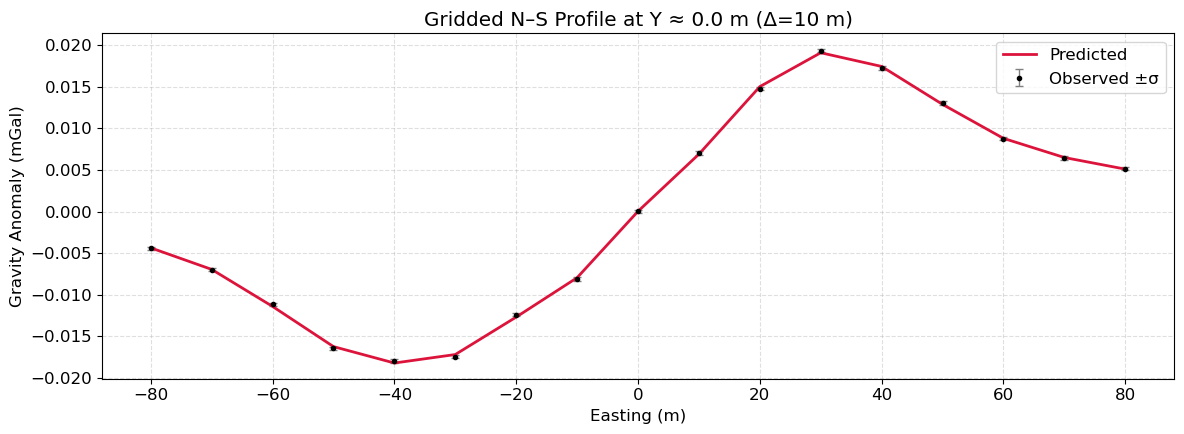

In [23]:
# --- Grid data, then extract a Y=0 profile for observed & predicted (with ±uncertainty) ---

# Inputs
xy = receiver_list[0].locations[:, :2]                  # (Easting, Northing)
dobs_zconv = dobs.ravel() * -1
dpred_zconv = np.asarray(inv_prob.dpred[0]).ravel() * -1
unc  = uncertainties.ravel()

# Regular grid
grid_res = 10.0                                         # meters
xi = np.arange(xy[:,0].min(), xy[:,0].max()+grid_res, grid_res)
yi = np.arange(xy[:,1].min(), xy[:,1].max()+grid_res, grid_res)
GX, GY = np.meshgrid(xi, yi)

def grid_with_fill(xy, v):
    g = griddata(xy, v, (GX, GY), method="linear")
    g_nn = griddata(xy, v, (GX, GY), method="nearest")
    return np.where(np.isnan(g), g_nn, g)

obs_g = grid_with_fill(xy, dobs_zconv)
pre_g = grid_with_fill(xy, dpred_zconv)
err_g = grid_with_fill(xy, unc)

# Extract profile at Y ≈ 0 (closest grid row)
y_target = 0.0
iy = np.argmin(np.abs(yi - y_target))
y_val = yi[iy]

x_prof  = xi
obs_prof = obs_g[iy, :]
pre_prof = pre_g[iy, :]
err_prof = err_g[iy, :]

# Mask any remaining NaNs (edges)
m = ~np.isnan(obs_prof) & ~np.isnan(pre_prof) & ~np.isnan(err_prof)
x_prof, obs_prof, pre_prof, err_prof = x_prof[m], obs_prof[m], pre_prof[m], err_prof[m]

# Plot
plt.figure(figsize=(12, 4.5))
plt.errorbar(x_prof, obs_prof, yerr=err_prof, fmt='o', ms=3, color='k',
             ecolor='0.5', elinewidth=1, capsize=3, label='Observed ±σ')
plt.plot(x_prof, pre_prof, '-', lw=2, color='crimson', label='Predicted')
plt.xlabel("Easting (m)")
plt.ylabel("Gravity Anomaly (mGal)")
plt.title(f"Gridded N–S Profile at Y ≈ {y_val:.1f} m (Δ={grid_res:.0f} m)")
plt.grid(True, ls='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


### Result: Noise Floor Set Too Low

With this inversion, the uncertainties were intentionally set **lower** than our **known noise level** (i.e. 1% versus 5% of the injected noise).

- **Objective function:**  
  $
  \phi(m) \;=\; \underbrace{\|\,W_d\,(d_\text{obs}-d_\text{pred}(m))\|_2^2}_{\phi_d \text{ (data misfit)}} \;+\; \beta\,\underbrace{\phi_m(m)}_{\text{regularization}}
  $  

    
1. **Data are over-weighted.**  
   Smaller $\sigma_i \Rightarrow$ larger weights $1/\sigma_i$. The data misfit $\phi_d$ dominates, so the solver tries to fit **every wiggle**, including **noise**.

2. **Regularization gets ignored.**  
   Because $\phi_d$ is so strong, the smoothness term $\phi_m$ can’t do its job. The model often looks **speckled**, **high-contrast**, and may show **artifacts**.

3. **Target misfit $\chi^2 \approx N$ becomes unrealistic.**  
   With tiny $\sigma$, $\phi_d$ is **too large**. You either (a) **can’t reach $N$** without making a very noisy model, or (b) reach $N$ only after heavy $\beta$ cooling, which **overfits** the data.

4. **Residuals reveal the problem.**  
   The normalized residuals $(d_\text{obs}-d_\text{pred})/\sigma$ spread **much larger than 1** if you avoid overfitting; if you force a fit, they look small but the **model is noisy**.

---

## Changing the uncertainty and rerunning inversion

### **Third pass** (when assigned uncertainties are just appropriate):
This time we will asign an optimal noise for the data. We use 5% of the maximum amplitude, similar to the injected gaussian noise.

In [ ]:
# Reassigning uncertainties
uncertainties = 0.05 * maximum_anomaly * np.ones(np.shape(dobs)) # 5% of the max anomaly

# Reassign data object
data_object = data.Data(survey, dobs=dobs, standard_deviation=uncertainties)

# Data misfit term
dmis = data_misfit.L2DataMisfit(data=data_object, simulation=simulation)

# Inverse problem
inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt)

# Here we combine the inverse problem and the set of directives
inv = inversion.BaseInversion(inv_prob, directives_list)

# Re-run inversion
recovered_model_3 = inv.run(starting_model)

The callback on the ProjectedGNCG Optimization was replaced.

Running inversion with SimPEG v0.23.0.1.post2.dev38+mira.ga1cf0ec4a

                    simpeg.InvProblem is setting bfgsH0 to the inverse of the eval2Deriv.
                    ***Done using the default solver Pardiso and no solver_opts.***
                    
model has any nan: 0
=============================== Projected GNCG ===============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
x0 has any nan: 0
   0  8.12e+02  1.09e+04  0.00e+00  1.09e+04    2.17e+02      0              
   1  4.06e+02  1.17e+03  1.72e+00  1.87e+03    1.75e+02      0              
   2  2.03e+02  6.62e+02  2.60e+00  1.19e+03    1.50e+02      0   Skip BFGS  
   3  1.02e+02  3.85e+02  3.55e+00  7.45e+02    1.28e+02      0   Skip BFGS  
------------------------- STOP! -------------------------
1 : |fc-fOld| = 0.0000e+00 <= 

## Plotting True Model and Recovered Model for the **Third Pass**

i.e. the model recovered from an inversion considering assigned uncertainties of 5% of the maximum absolute observed anomaly.

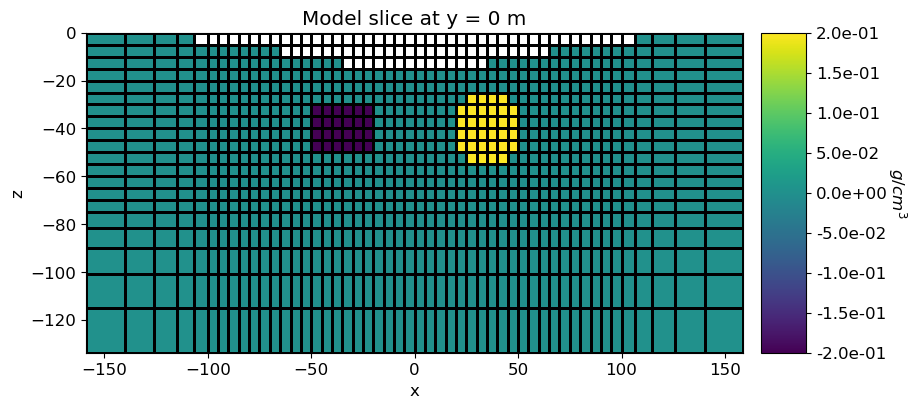

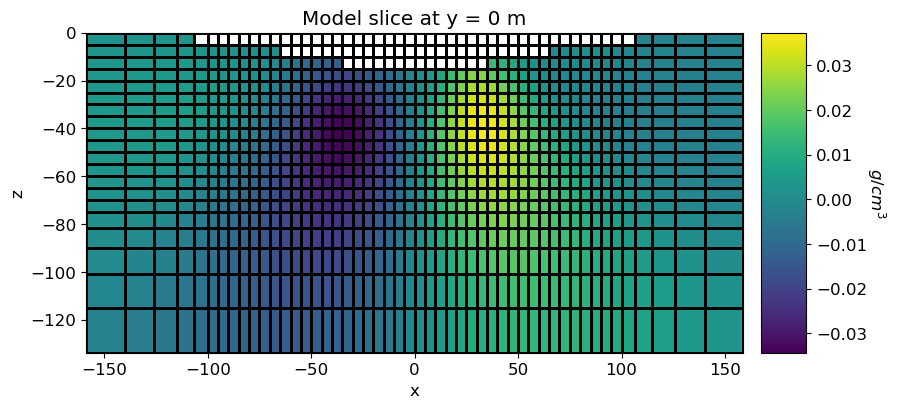

In [25]:
# Plot True Model
fig = plt.figure(figsize=(9, 4))
plotting_map = maps.InjectActiveCells(mesh, ind_active, np.nan)

ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])
mesh.plot_slice(
    plotting_map * true_model,
    normal="Y",
    ax=ax1,
    ind=int(mesh.shape_cells[1] / 2),
    grid=True,
    clim=(np.min(true_model), np.max(true_model)),
    pcolor_opts={"cmap": "viridis"},
)
ax1.set_title("Model slice at y = 0 m")


ax2 = fig.add_axes([0.85, 0.1, 0.05, 0.8])
norm = mpl.colors.Normalize(vmin=np.min(true_model), vmax=np.max(true_model))
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.viridis, format="%.1e"
)
cbar.set_label("$g/cm^3$", rotation=270, labelpad=15, size=12)

plt.show()

# Plot Recovered Model
fig = plt.figure(figsize=(9, 4))
plotting_map = maps.InjectActiveCells(mesh, ind_active, np.nan)

ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])
mesh.plot_slice(
    plotting_map * recovered_model_3,
    normal="Y",
    ax=ax1,
    ind=int(mesh.shape_cells[1] / 2),
    grid=True,
    clim=(np.min(recovered_model_3), np.max(recovered_model_3)),
    pcolor_opts={"cmap": "viridis"},
)
ax1.set_title("Model slice at y = 0 m")

ax2 = fig.add_axes([0.85, 0.1, 0.05, 0.8])
norm = mpl.colors.Normalize(vmin=np.min(recovered_model_3), vmax=np.max(recovered_model_3))
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.viridis
)
cbar.set_label("$g/cm^3$", rotation=270, labelpad=15, size=12)

plt.show()

## Plotting Predicted Data and Normalized Misfit for the **Third Pass**

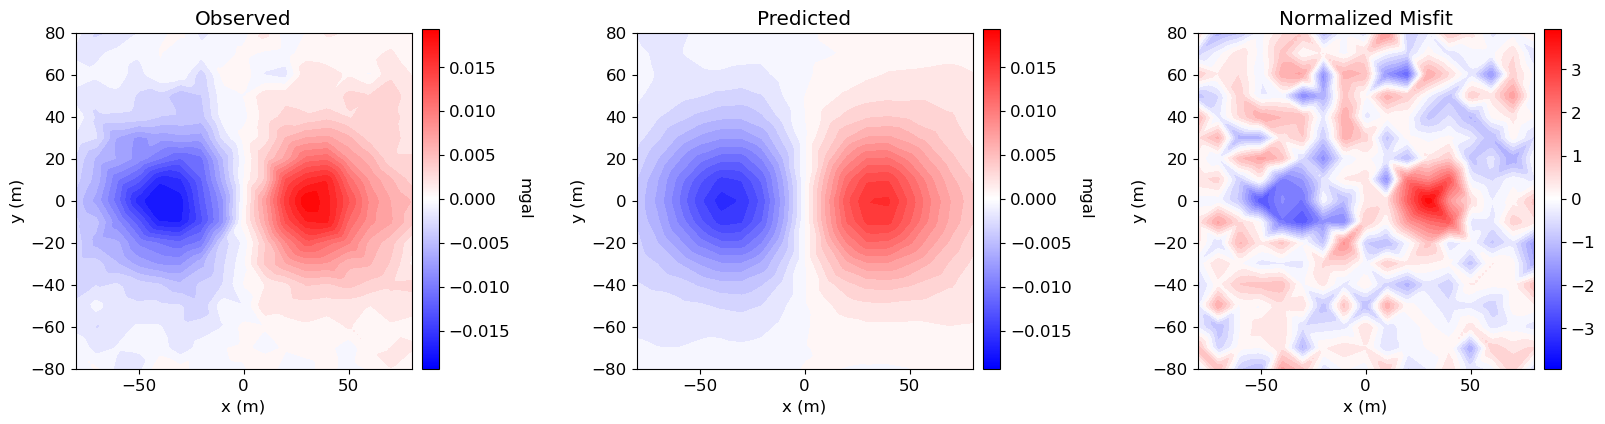

In [26]:
# Predicted data with final recovered model
# SimPEG uses right handed coordinate where Z is positive upward.
# This causes gravity signals look "inconsistent" with density values in visualization. Therefore we multiply by -1.
dpred_zconv = np.asarray(inv_prob.dpred[0].ravel())* -1
dobs_zconv = np.asarray(dobs.ravel())* -1

# Observed data | Predicted data | Normalized data misfit
data_array = np.c_[dobs_zconv, dpred_zconv, (dobs_zconv - dpred_zconv) / uncertainties]

fig = plt.figure(figsize=(17, 4))
plot_title = ["Observed", "Predicted", "Normalized Misfit"]
plot_units = ["mgal", "mgal", ""]

ax1 = 3 * [None]
ax2 = 3 * [None]
norm = 3 * [None]
cbar = 3 * [None]
cplot = 3 * [None]
v_lim = [np.max(np.abs(dobs)), np.max(np.abs(dobs)), np.max(np.abs(data_array[:, 2]))]

for ii in range(0, 3):
    ax1[ii] = fig.add_axes([0.33 * ii + 0.03, 0.11, 0.23, 0.84])
    cplot[ii] = plot2Ddata(
        receiver_list[0].locations,
        data_array[:, ii],
        ax=ax1[ii],
        ncontour=30,
        clim=(-v_lim[ii], v_lim[ii]),
        contourOpts={"cmap": "bwr"},
    )
    ax1[ii].set_title(plot_title[ii])
    ax1[ii].set_xlabel("x (m)")
    ax1[ii].set_ylabel("y (m)")

    ax2[ii] = fig.add_axes([0.33 * ii + 0.25, 0.11, 0.01, 0.85])
    norm[ii] = mpl.colors.Normalize(vmin=-v_lim[ii], vmax=v_lim[ii])
    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="vertical", cmap=mpl.cm.bwr
    )
    cbar[ii].set_label(plot_units[ii], rotation=270, labelpad=15, size=12)

plt.show()

## Plot Profile of Predicted Data and Normalized Misfit for the **Third Pass**

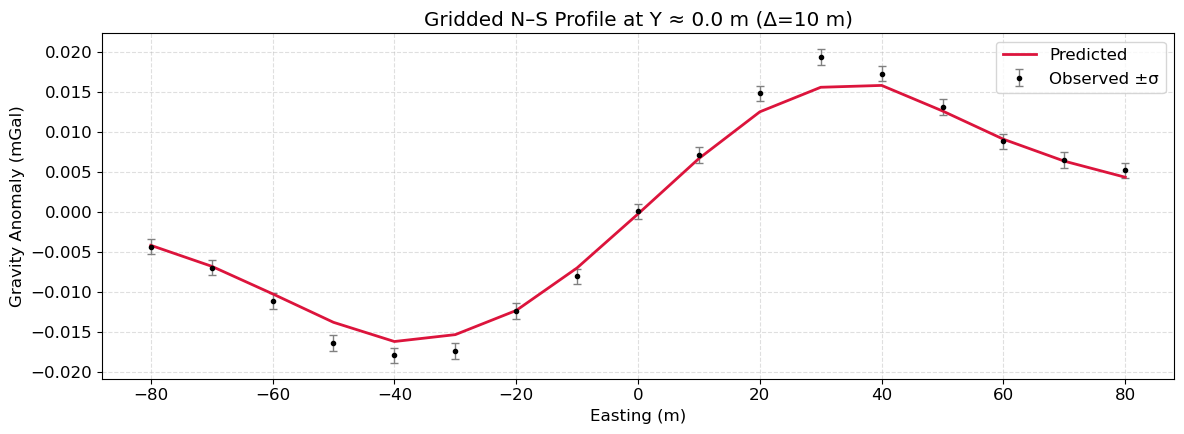

In [27]:
# --- Grid data, then extract a Y=0 profile for observed & predicted (with ±uncertainty) ---

# Inputs
xy = receiver_list[0].locations[:, :2]                  # (Easting, Northing)
dobs_zconv = dobs.ravel() * -1
dpred_zconv = np.asarray(inv_prob.dpred[0]).ravel() * -1
unc  = uncertainties.ravel()

# Regular grid
grid_res = 10.0                                         # meters
xi = np.arange(xy[:,0].min(), xy[:,0].max()+grid_res, grid_res)
yi = np.arange(xy[:,1].min(), xy[:,1].max()+grid_res, grid_res)
GX, GY = np.meshgrid(xi, yi)

def grid_with_fill(xy, v):
    g = griddata(xy, v, (GX, GY), method="linear")
    g_nn = griddata(xy, v, (GX, GY), method="nearest")
    return np.where(np.isnan(g), g_nn, g)

obs_g = grid_with_fill(xy, dobs_zconv)
pre_g = grid_with_fill(xy, dpred_zconv)
err_g = grid_with_fill(xy, unc)

# Extract profile at Y ≈ 0 (closest grid row)
y_target = 0.0
iy = np.argmin(np.abs(yi - y_target))
y_val = yi[iy]

x_prof  = xi
obs_prof = obs_g[iy, :]
pre_prof = pre_g[iy, :]
err_prof = err_g[iy, :]

# Mask any remaining NaNs (edges)
m = ~np.isnan(obs_prof) & ~np.isnan(pre_prof) & ~np.isnan(err_prof)
x_prof, obs_prof, pre_prof, err_prof = x_prof[m], obs_prof[m], pre_prof[m], err_prof[m]

# Plot
plt.figure(figsize=(12, 4.5))
plt.errorbar(x_prof, obs_prof, yerr=err_prof, fmt='o', ms=3, color='k',
             ecolor='0.5', elinewidth=1, capsize=3, label='Observed ±σ')
plt.plot(x_prof, pre_prof, '-', lw=2, color='crimson', label='Predicted')
plt.xlabel("Easting (m)")
plt.ylabel("Gravity Anomaly (mGal)")
plt.title(f"Gridded N–S Profile at Y ≈ {y_val:.1f} m (Δ={grid_res:.0f} m)")
plt.grid(True, ls='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


### Result: Noise Floor Set Just Right 

With this inversion, the uncertainties were set **just right** i.e. very similar to our injected **Gaussian noise level** (≈ 5% of total amplitude).

- **Objective function:**  
  $
  \phi(m) \;=\; \underbrace{\|\,W_d\,(d_\text{obs}-d_\text{pred}(m))\|_2^2}_{\phi_d \text{ (data misfit)}} \;+\; \beta\,\underbrace{\phi_m(m)}_{\text{regularization}}
  $  


1. **Weights are balanced.**  
   $\sigma_i$ matches the true noise level, so the weights $1/\sigma_i$ are neither too large nor too small. The data-misfit $\phi_d$ has the “right” influence in $\phi(m)$.

2. **Data fit vs. smoothness is in balance.**  
   The inversion fits the data well **without** chasing noise. Structures are recovered with reasonable contrast and geometry, and the model isn’t overly rough or overly smooth.  
   We note that due to the nature of the L2 regularization used, the model will still exhibit smooth transitions, but the center of the anomaly is well-positioned and defined.

3. **Residuals look like noise.**  
   The normalized residuals $(d_\text{obs}-d_\text{pred})/\sigma$ are centered near zero with a spread $\approx 1$. Residual maps show no obvious geologic patterns, just random-looking variation.

4. **Target misfit is meaningful.**  
   The run reaches the expected level $\phi_d \approx N$ at a sensible point in the $\beta$ schedule. Further steps (e.g., IRLS) can add compactness without overfitting.

**Quick checks:** $\phi_d/N \approx 1$, RMS $\approx \sigma$, residual histogram $\sim \mathcal{N}(0,1)$.
